# 06 - The Transformer block

A GPT is just a stack of identical **Transformer blocks**, one on top of the next. You can picture each block as a short team meeting with two phases:

1. **multi-head self-attention**, where everyone shares information (each token gathers context from the others),
2. a **feed-forward network**, where everyone goes back to their desk and thinks it over alone.

Two supports keep the meeting orderly: **residual connections** (keep the original notes and just add edits on top) and **LayerNorm** (keep everyone's numbers on a similar scale). And because attention on its own has no sense of word order, we first stamp each token with its **position**. We will build every piece in NumPy and run one full block's forward pass.

In [1]:
import numpy as np
np.random.seed(1337)
def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True); e = np.exp(x); return e / e.sum(axis=axis, keepdims=True)

B, T, C = 4, 16, 64       # batch, time, embedding dim
n_head = 4

<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>import numpy as np; np.random.seed(1337)</code>: the array toolbox, randomness pinned.</li>
<li><code>def softmax(x, axis=-1): ...</code>: the usual scores-to-probabilities helper.</li>
<li><code>B, T, C = 4, 16, 64</code>: 4 sequences, 16 tokens each, 64 numbers per token.</li>
<li><code>n_head = 4</code>: we'll split those 64 numbers across 4 attention heads (16 each).</li>
</ul>
</details>

## Positional encoding

Attention is **order-blind**. It is just a weighted sum, so if you shuffled the tokens it would return the same outputs (shuffled the same way); it has no idea which token came first. But order carries meaning, since "dog bites man" and "man bites dog" are very different. So before anything else we stamp each token with its position, adding a position signature onto its embedding (the embedding being the list of numbers that represents the token).

The classic method uses **sinusoids**, which are simply waves of different speeds. Think of a car's mileage counter: a fast-spinning ones wheel, a slower tens wheel, and a slower-still hundreds wheel. Read together, the mix of fast and slow wheels gives every position a unique fingerprint, and nearby positions get similar fingerprints. (A GPT actually learns its own table of position signatures instead of using fixed waves, but both achieve the same thing.)

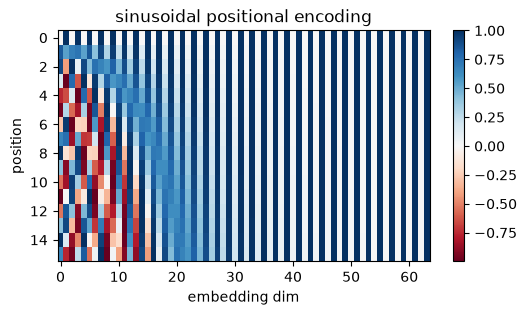

In [2]:
def positional_encoding(T, C):
    pos = np.arange(T)[:, None]
    i = np.arange(C)[None, :]
    angle = pos / np.power(10000, (2 * (i // 2)) / C)
    pe = np.where(i % 2 == 0, np.sin(angle), np.cos(angle))
    return pe                              # (T, C)

pe = positional_encoding(T, C)
import matplotlib.pyplot as plt
plt.figure(figsize=(6,3)); plt.imshow(pe, aspect="auto", cmap="RdBu")
plt.xlabel("embedding dim"); plt.ylabel("position"); plt.title("sinusoidal positional encoding"); plt.colorbar(); plt.show()

<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>def positional_encoding(T, C):</code>: build a unique "where am I" fingerprint for each of the T positions.</li>
<li><code>pos = np.arange(T)[:, None]</code>: positions 0..15 as a <i>column</i> (the <code>[:, None]</code> adds an axis so it can broadcast against a row).</li>
<li><code>i = np.arange(C)[None, :]</code>: the embedding-slot numbers 0..63 as a <i>row</i>.</li>
<li><code>angle = pos / np.power(10000, (2 * (i // 2)) / C)</code>: the wave math. <code>i // 2</code> is whole-number division, pairing slots (0,0,1,1,...); each pair gets its own wave speed -- small <code>i</code> &rarr; divisor near 1 &rarr; fast wave, large <code>i</code> &rarr; divisor near 10000 &rarr; very slow wave. Fast and slow wheels, like an odometer.</li>
<li><code>np.where(i % 2 == 0, np.sin(angle), np.cos(angle))</code>: even slots take the sine of their angle, odd slots the cosine (<code>%</code> is remainder). Together every position gets a one-of-a-kind pattern of wave readings.</li>
<li><code>plt.imshow(pe, ...)</code>: draw it: rows are positions, columns are slots; you can see fast stripes on the left, slow on the right.</li>
</ul>
</details>

## LayerNorm

As signals pass through many layers, the numbers can drift, either ballooning very large or shrinking towards nothing, and training then falls apart. **LayerNorm** is the fix. For each token it takes that token's list of numbers and rescales it to have an average of 0 and a **standard deviation** of 1. (Standard deviation is just a measure of how spread out a set of numbers is; forcing it to 1 keeps the spread consistent, rather like grading on a curve.) It then applies two learned dials, `gamma` and `beta`, so the model can stretch or shift the result if that helps.

The cell shows it working: numbers that started with an average of 0.44 and a spread of 5.02 come out at an average of 0 and a spread of 1. This is done for each token on its own and has nothing to do with the rest of the batch, which is what separates it from an older method called BatchNorm, and why it behaves the same whether you process one sequence or a thousand.

In [3]:
def layer_norm(x, gamma, beta, eps=1e-5):
    mu = x.mean(axis=-1, keepdims=True)
    var = x.var(axis=-1, keepdims=True)
    return gamma * (x - mu) / np.sqrt(var + eps) + beta

z = np.random.randn(2, 5) * 5 + 3
zn = layer_norm(z, 1.0, 0.0)
print("before: mean=%.2f std=%.2f" % (z.mean(), z.std()))
print("after : mean=%.2f std=%.2f  (per-row normalized)" % (zn.mean(), zn.std()))

before: mean=0.44 std=5.02
after : mean=0.00 std=1.00  (per-row normalized)


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>def layer_norm(x, gamma, beta, eps=1e-5):</code>: rescale each token's vector to a standard size so deep stacks stay stable.</li>
<li><code>mu = x.mean(axis=-1, keepdims=True)</code>: each token-vector's average (across its own features).</li>
<li><code>var = x.var(axis=-1, keepdims=True)</code>: its variance: how spread out those numbers are.</li>
<li><code>(x - mu) / np.sqrt(var + eps)</code>: the recipe in words: shift so the average is 0, divide by the spread so it becomes 1. <code>eps</code> (a tiny 0.00001) is insurance against dividing by zero if a vector is perfectly flat.</li>
<li><code>gamma * ... + beta</code>: two learned dials to scale and shift the normalized result. We pass 1.0 and 0.0 ("leave it as is"); a real model learns them.</li>
<li>The test: numbers built with mean 3 and spread 5 come out at mean 0, spread 1 -- row by row.</li>
</ul>
</details>

### Watch LayerNorm flatten a token

LayerNorm's job is one sentence: take a token's row of numbers and rescale it to mean 0, standard deviation 1. The cell above printed the overall stats; here it is per row, before and after, with row 0 drawn as bars. However spread out a row starts, it lands on the same scale.

before row 0: mean=-0.06  std=3.23
before row 1: mean=+0.95  std=6.29
after  row 0: mean=+0.00  std=1.00
after  row 1: mean=+0.00  std=1.00


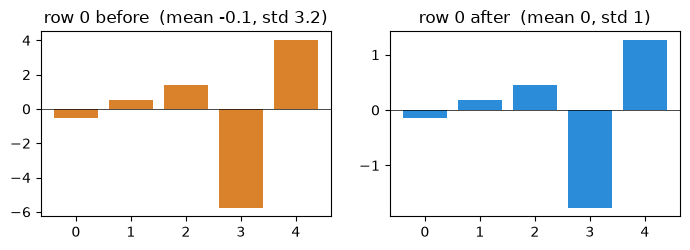

In [4]:
# LayerNorm rescales EACH row to mean 0, std 1 -- per row, then row 0 as bars.
for r in range(z.shape[0]):
    print(f"before row {r}: mean={z[r].mean():+.2f}  std={z[r].std():.2f}")
for r in range(zn.shape[0]):
    print(f"after  row {r}: mean={zn[r].mean():+.2f}  std={zn[r].std():.2f}")

fig, ax = plt.subplots(1, 2, figsize=(7, 2.6))
idx = np.arange(z.shape[1])
ax[0].bar(idx, z[0], color="#d9822b"); ax[0].axhline(0, color="k", lw=.5)
ax[0].set_title("row 0 before  (mean %.1f, std %.1f)" % (z[0].mean(), z[0].std()))
ax[1].bar(idx, zn[0], color="#2b8dd9"); ax[1].axhline(0, color="k", lw=.5)
ax[1].set_title("row 0 after  (mean 0, std 1)")
plt.tight_layout(); plt.show()

<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li>The two loops print each row's mean and standard deviation, first for the raw <code>z</code>, then for the normalized <code>zn</code>.</li>
<li>Row 1 starts wildly spread (std over 6); after LayerNorm every row reads mean 0.00, std 1.00.</li>
<li>The left bars are row 0 raw -- off-centre and uneven; the right bars are the same row after -- centred on 0 with a consistent spread.</li>
<li><code>gamma</code> and <code>beta</code> (here 1 and 0) then let the model rescale and shift if it wants, but the starting point is always this clean, fixed scale.</li>
</ul>
</details>

## Multi-head attention

A single attention head can only look for one kind of relationship at a time. **Multi-head attention** runs several heads in parallel so the model can look for several at once: perhaps one head links each verb to its subject, another tracks quotation marks, and another watches for the previous line break. It is like a panel of specialists, each reading the sentence for their own purpose and then pooling their notes.

Mechanically, we slice the embedding into `n_head` equal pieces, run a separate attention head (exactly the one from notebook 05) on each piece in parallel, glue the results back together (concatenate them), and pass them through one more projection `Wo` that lets the heads mix. The output has the same shape as the input, so it drops straight into the block.

In [5]:
def multi_head_attention(x, Wq, Wk, Wv, Wo, n_head):
    B, T, C = x.shape
    hs = C // n_head
    def proj(W): return (x @ W).reshape(B, T, n_head, hs).transpose(0, 2, 1, 3)  # (B,nh,T,hs)
    q, k, v = proj(Wq), proj(Wk), proj(Wv)
    scores = (q @ k.transpose(0, 1, 3, 2)) / hs**0.5              # (B,nh,T,T)
    scores = np.where(np.tril(np.ones((T, T))) == 0, -np.inf, scores)
    attn = softmax(scores, axis=-1)
    out = attn @ v                                                # (B,nh,T,hs)
    out = out.transpose(0, 2, 1, 3).reshape(B, T, C)             # concat heads
    return out @ Wo                                              # output projection

Wq = np.random.randn(C, C)*0.02; Wk = np.random.randn(C, C)*0.02
Wv = np.random.randn(C, C)*0.02; Wo = np.random.randn(C, C)*0.02
x = np.random.randn(B, T, C)
print("multi-head output:", multi_head_attention(x, Wq, Wk, Wv, Wo, n_head).shape)

multi-head output: (4, 16, 64)


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>def multi_head_attention(x, Wq, Wk, Wv, Wo, n_head):</code>: run several attention heads at once and combine them.</li>
<li><code>hs = C // n_head</code>: whole-number division: 64 features split across 4 heads = 16 each.</li>
<li><code>def proj(W): return (x @ W).reshape(B, T, n_head, hs).transpose(0, 2, 1, 3)</code>: one helper used three times: project, then <code>reshape</code> carves the 64-wide result into 4 heads of 16, and <code>transpose</code> reorders the axes to (batch, head, time, hs) so every head can work independently.</li>
<li><code>q, k, v = proj(Wq), proj(Wk), proj(Wv)</code>: queries, keys, values, all carved into heads.</li>
<li><code>scores = (q @ k.transpose(0, 1, 3, 2)) / hs**0.5</code>: notebook 05's scaled query-key scores, now with a head axis riding along: 4 separate (T,T) grids per sequence.</li>
<li><code>scores = np.where(np.tril(...) == 0, -np.inf, scores)</code>: the causal mask, applied to every head at once.</li>
<li><code>out = attn @ v</code> then <code>.transpose(...).reshape(B, T, C)</code>: blend values per head, then undo the carving so the 4 heads' 16-number outputs sit side by side as 64 again ("concatenate").</li>
<li><code>return out @ Wo</code>: one final projection lets the heads' findings mix with each other.</li>
</ul>
</details>

### How `C` splits into heads

The reshape inside `multi_head_attention` is the one line that trips people up. All it does is cut each token's projected vector into `n_head` equal slices, run attention on every slice in parallel, then glue the results back and mix them with `Wo`. Here are the shapes at each step, and a picture of the split.

C = 64  ->  4 heads of head_size = 16

x @ Wq                  : (4, 16, 64)    (B, T, C)
reshape + move heads up : (4, 4, 16, 16)    (B, n_head, T, head_size)
per-head attention q@k.T: (4, 4, 16, 16)    one T x T map per head
glue heads back         : (4, 16, 64)    then a final @ Wo mixes them


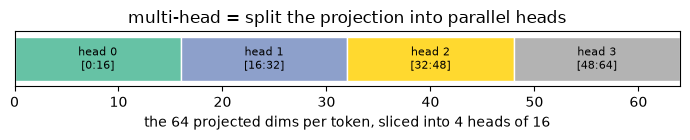

In [6]:
# Trace the shapes through one multi-head pass, then draw the head split.
hs = C // n_head
print(f"C = {C}  ->  {n_head} heads of head_size = {hs}\n")
print("x @ Wq                  :", (x @ Wq).shape, "   (B, T, C)")
qh = (x @ Wq).reshape(B, T, n_head, hs).transpose(0, 2, 1, 3)
print("reshape + move heads up :", qh.shape, "   (B, n_head, T, head_size)")
print("per-head attention q@k.T:", (B, n_head, T, T), "   one T x T map per head")
print("glue heads back         :", (B, T, C), "   then a final @ Wo mixes them")

fig, ax = plt.subplots(figsize=(7, 1.5))
colors = plt.cm.Set2(np.linspace(0, 1, n_head))
for hi in range(n_head):
    ax.barh(0, hs, left=hi * hs, color=colors[hi], edgecolor="white")
    ax.text(hi * hs + hs / 2, 0, f"head {hi}\n[{hi*hs}:{hi*hs+hs}]", ha="center", va="center", fontsize=8)
ax.set_xlim(0, C); ax.set_ylim(-0.5, 0.5); ax.set_yticks([])
ax.set_xlabel(f"the {C} projected dims per token, sliced into {n_head} heads of {hs}")
ax.set_title("multi-head = split the projection into parallel heads")
plt.tight_layout(); plt.show()

<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>x @ Wq</code>: project every token, still <code>(B, T, C)</code> -- nothing split yet.</li>
<li><code>.reshape(B, T, n_head, hs).transpose(...)</code>: cut the C numbers into <code>n_head</code> slices of <code>head_size</code>, and move the head axis up so each head is an independent <code>(T, head_size)</code> block.</li>
<li>Each head then runs the exact attention from notebook 05 on its own slice, giving one <code>T x T</code> map per head.</li>
<li>The outputs are glued back into <code>(B, T, C)</code> and passed through <code>Wo</code>, which lets the heads' findings mix.</li>
<li>The coloured bar is the split: dims 0-15 are head 0, 16-31 head 1, and so on -- parallel heads, each watching for a different kind of relationship.</li>
</ul>
</details>

## Feed-forward network

Attention let the tokens talk to each other; now each token thinks on its own. The feed-forward network is a small two-layer MLP (multi-layer perceptron, from notebook 04) applied to every token independently. It **expands** the vector to width `4*C`, four times wider, giving it room to compute richer features; passes it through a **nonlinearity** (here GELU, a smooth on/off gate that roughly keeps positive values and suppresses negative ones); and then **projects it back** down to width `C`.

That nonlinearity is essential. Without a bend in it, stacking layers would collapse into a single straight-line layer that cannot learn curves or rules. This sub-layer holds most of the model's numbers, and much of what we would loosely call its "knowledge" lives here.

In [7]:
def gelu(x):
    return 0.5 * x * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715 * x**3)))

def feed_forward(x, W1, b1, W2, b2):
    return gelu(x @ W1 + b1) @ W2 + b2

W1 = np.random.randn(C, 4*C)*0.02; b1 = np.zeros(4*C)
W2 = np.random.randn(4*C, C)*0.02; b2 = np.zeros(C)
print("feed-forward output:", feed_forward(x, W1, b1, W2, b2).shape)

feed-forward output: (4, 16, 64)


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>def gelu(x):</code>: the gentle on/off gate. The exact formula is a standard fast approximation; what matters is the <i>shape</i>: very negative inputs &rarr; near 0 (off), positive inputs &rarr; near x (passed through), with a smooth bend instead of a hard corner.</li>
<li><code>def feed_forward(x, W1, b1, W2, b2):</code>: the per-token "think about it" network.</li>
<li><code>gelu(x @ W1 + b1) @ W2 + b2</code>: the whole thing in one line: widen (64 &rarr; 256), bend with GELU, narrow back (256 &rarr; 64). <code>b1</code>/<code>b2</code> are bias vectors added to every token by broadcasting.</li>
<li><code>W1 = np.random.randn(C, 4*C)*0.02; b1 = np.zeros(4*C)</code>: weights start small-random, biases start at zero.</li>
</ul>
</details>

### Is the approximation good enough to trust?

A constant like `0.044715` invites a fair question: how much is being given up? GELU's real definition is *x times the probability a standard bell curve falls below x*, and that probability needs the error function, which is slow. The `tanh` expression is a stand-in, and those constants were chosen so the cheap curve lies on top of the expensive one. It is measurable, so measure it.

In [8]:
from math import erf

def gelu_exact(x):
    phi = np.array([0.5 * (1 + erf(v / 2**0.5))
                    for v in np.atleast_1d(x)])
    return x * phi

xs = np.array([-3.0, -1.0, 0.0, 1.0, 3.0])
print("   x    approx     exact      diff")
for a, b, c in zip(xs, gelu(xs), gelu_exact(xs)):
    print(f"{a:5.1f} {b:9.5f} {c:9.5f} {abs(b-c):9.6f}")

wide = np.linspace(-5, 5, 2001)
print("largest gap in -5..5:",
      round(float(np.abs(gelu(wide)
                         - gelu_exact(wide)).max()), 6))


   x    approx     exact      diff
 -3.0  -0.00364  -0.00405  0.000412
 -1.0  -0.15881  -0.15866  0.000153
  0.0   0.00000   0.00000  0.000000
  1.0   0.84119   0.84134  0.000153
  3.0   2.99636   2.99595  0.000412
largest gap in -5..5: 0.000473


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>0.5 * (1 + erf(v / 2**0.5))</code>: the probability a standard bell curve falls below <code>v</code>. This is the definition the approximation is imitating, computed the slow exact way.</li>
<li><code>for a, b, c in zip(xs, gelu(xs), gelu_exact(xs)):</code>: line up the cheap curve against the exact one at five points.</li>
<li><code>np.linspace(-5, 5, 2001)</code>: rather than trust five hand-picked points, sweep two thousand across the range any real activation lands in. The largest disagreement anywhere is 0.000473 &mdash; the two magic constants buy a curve that matches the real thing to about four decimal places, using an operation the hardware already had. That is why you meet <code>0.044715</code> in every GPT implementation you ever read, always unexplained, always the same.</li>
</ul>
</details>

### See the GELU gate, and the width change

The feed-forward network does two things worth seeing. Every token passes through GELU, the "smooth on/off gate" the text mentions -- so here it is, plotted against the blunt ReLU. And it briefly widens each token from `C` to `4*C` and back, which is where its extra room to compute lives.

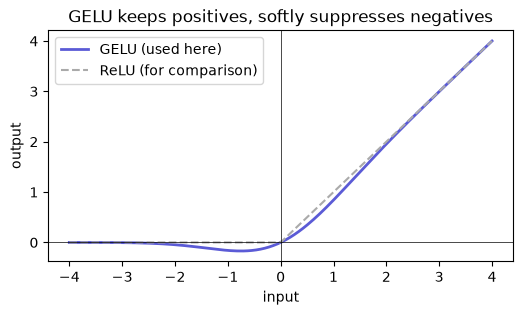

feed-forward width per token:  64  ->  256  (expand + GELU)  ->  64  (contract)
W1: (64, 256)   W2: (256, 64)


In [9]:
# GELU vs ReLU, then the expand-then-contract widths of the feed-forward net.
xs = np.linspace(-4, 4, 200)
plt.figure(figsize=(6, 3))
plt.plot(xs, gelu(xs), label="GELU (used here)", color="#5b5bd6", lw=2)
plt.plot(xs, np.maximum(xs, 0), label="ReLU (for comparison)", color="#aaa", ls="--")
plt.axhline(0, color="k", lw=.5); plt.axvline(0, color="k", lw=.5)
plt.legend(); plt.title("GELU keeps positives, softly suppresses negatives")
plt.xlabel("input"); plt.ylabel("output"); plt.show()

print(f"feed-forward width per token:  {C}  ->  {4*C}  (expand + GELU)  ->  {C}  (contract)")
print(f"W1: {W1.shape}   W2: {W2.shape}")

<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>xs = np.linspace(-4, 4, 200)</code>: a range of inputs to feed the activation.</li>
<li><code>plt.plot(xs, gelu(xs))</code>: GELU's smooth S-curve -- it passes large positives through almost unchanged and eases negatives toward zero, with a soft dip near -1 rather than ReLU's hard corner.</li>
<li>The dashed ReLU (<code>max(x, 0)</code>) is drawn for contrast: same idea, blunt instead of smooth.</li>
<li>The prints show the width change: each token goes <code>64 -> 256 -> 64</code>. The wide middle (four times C) is the room the network computes richer features in before shrinking back.</li>
</ul>
</details>

## Assemble the block (pre-norm, with residuals)

Now we wire the two sub-layers together. Modern GPTs use the **pre-norm** arrangement: apply LayerNorm first, then the sub-layer, then add the result back to the input. That "add back" is the **residual** (or skip) connection, and it is worth pausing on:

```
x = x + MultiHeadAttention(LayerNorm(x))
x = x + FeedForward(LayerNorm(x))
```

Read each line as "keep `x`, and add an improvement on top." Each sub-layer only has to learn a small edit to the running representation, rather than rebuilding it from scratch. Just as important, the `x +` gives the gradients a clean route straight back through the whole stack during the backward pass; without residuals, deep Transformers simply do not train, because the gradient fades to nothing before it reaches the early layers.

Stacking the block three times below returns the same shape it took in, which is the whole point: identical blocks can be stacked, and a real GPT simply stacks more of them.

In [10]:
def transformer_block(x, params):
    p = params
    # sub-layer 1: attention, with a residual connection
    a = multi_head_attention(layer_norm(x, p['g1'], p['b1']), p['Wq'], p['Wk'], p['Wv'], p['Wo'], n_head)
    x = x + a
    # sub-layer 2: feed-forward, with a residual connection
    f = feed_forward(layer_norm(x, p['g2'], p['b2']), p['W1'], p['ff_b1'], p['W2'], p['ff_b2'])
    x = x + f
    return x

params = dict(
    g1=np.ones(C), b1=np.zeros(C), g2=np.ones(C), b2=np.zeros(C),
    Wq=Wq, Wk=Wk, Wv=Wv, Wo=Wo,
    W1=W1, ff_b1=b1, W2=W2, ff_b2=b2,
)
# token embeddings + positional encoding go in; same shape comes out
h = x + positional_encoding(T, C)
for _ in range(3):                 # stack 3 blocks
    h = transformer_block(h, params)
print("after 3 blocks:", h.shape, " (shape preserved -> blocks are stackable)")
print("finite:", np.isfinite(h).all())

after 3 blocks: (4, 16, 64)  (shape preserved -> blocks are stackable)
finite: True


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>def transformer_block(x, params):</code>: wire the two sub-layers together; <code>params</code> is a dictionary holding every weight, so <code>p['Wq']</code> fetches the query projection, etc.</li>
<li><code>a = multi_head_attention(layer_norm(x, ...), ...)</code>: read inside-out: normalize, then attend.</li>
<li><code>x = x + a</code>: <b>add the attention result back onto x</b>. That <code>x +</code> is the residual: keep the original, add an edit on top.</li>
<li><code>f = feed_forward(layer_norm(x, ...), ...)</code> then <code>x = x + f</code>: the same normalize &rarr; think &rarr; add-back pattern for the second sub-layer.</li>
<li><code>params = dict(g1=np.ones(C), b1=np.zeros(C), ...)</code>: bundle all the pieces: LayerNorm dials (set to "no change"), the four attention grids, the two feed-forward grids and biases.</li>
<li><code>h = x + positional_encoding(T, C)</code>: stamp positions onto the tokens before the first block.</li>
<li><code>for _ in range(3): h = transformer_block(h, params)</code>: stack three blocks. Same shape out as in, every time -- which is exactly what lets you stack them.</li>
<li><code>np.isfinite(h).all()</code>: a health check: no infinities or NaNs anywhere after 3 blocks.</li>
</ul>
</details>

### Residuals: keep `x`, add a small correction

Both block lines read `x = x + something`. That "+ x" is the residual connection. Measure the size (root-mean-square) of each piece and you can see what it buys: each sub-layer adds only a small correction on top of `x`, and the block's output stays on the same scale as its input.

In [11]:
# Measure the size of each quantity a block produces (rms = typical magnitude).
def rms(t): return float(np.sqrt((t ** 2).mean()))

x0 = x + positional_encoding(T, C)                                        # block input
a = multi_head_attention(layer_norm(x0, params["g1"], params["b1"]), Wq, Wk, Wv, Wo, n_head)
x1 = x0 + a                                                               # first residual add
f = feed_forward(layer_norm(x1, params["g2"], params["b2"]), W1, b1, W2, b2)
x2 = x1 + f                                                               # second residual add

print(f"block input  x          : rms = {rms(x0):.3f}")
print(f"attention correction  a : rms = {rms(a):.3f}    <- added:  x = x + a")
print(f"feed-forward corr.    f : rms = {rms(f):.3f}    <- added:  x = x + f")
print(f"block output  x+a+f     : rms = {rms(x2):.3f}    (same scale as the input)")
print("\nThe corrections are small on purpose: small initial weights make each block")
print("start as ALMOST the identity (output ~ input). The residual is what preserves")
print("the scale, so you can stack many blocks and still train them.")

block input  x          : rms = 1.213
attention correction  a : rms = 0.014    <- added:  x = x + a
feed-forward corr.    f : rms = 0.027    <- added:  x = x + f
block output  x+a+f     : rms = 1.214    (same scale as the input)

The corrections are small on purpose: small initial weights make each block
start as ALMOST the identity (output ~ input). The residual is what preserves
the scale, so you can stack many blocks and still train them.


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>rms(t)</code>: the root-mean-square, a single number for "how big are these values typically".</li>
<li><code>x0</code>: the block's input (token embeddings plus positions), rms about 1.2.</li>
<li><code>a</code> and <code>f</code>: the attention and feed-forward outputs -- both much smaller than <code>x0</code>, so <code>x = x + a</code> and <code>x = x + f</code> nudge the signal rather than overwrite it.</li>
<li>The output stays on the same scale as the input, which is exactly why cell above could stack three blocks and stay finite.</li>
<li>Small corrections at the start (from small weights) mean the block begins near the identity and training gently grows it -- the residual is what makes that possible.</li>
</ul>
</details>

## The wall we have just hit, on purpose

We have built the entire forward pass of a Transformer by hand. Notice what we did not do: the backward pass. Differentiating multi-head attention, LayerNorm, the residuals, and the feed-forward stack by hand, the way we did for the bigram in notebook 03, would be hundreds of careful and error-prone lines, and a single wrong sign would break the whole thing silently.

This is exactly the moment autograd (notebook 04) earns its place. In Part 2 we rebuild all of this in **PyTorch**, where every operation we just wrote already knows how to compute its own gradient. The concepts are the same, the code is a fraction of the length, and it actually trains.

Next: notebook 07, PyTorch and autograd.